kernel: 3.9.6 (.venv)

## Imports

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import cplex

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import cvxpy as cp

from datetime import datetime, timedelta
from math import sqrt

%matplotlib inline


/Users/alinavoronina/Documents/UofT/finance/financial_FINAL/.venv/lib/python3.9/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
model = "gpt-4"
avg_weights = True

Install CPLEX solver. To setup CPLEX solver for Python:
* Use the script `setup.py` located in the directory `yourCPLEXhome/python`
* Execute the following command from the command line `python yourCPLEXhome/python/setup.py install` or `python yourCPLEXhome/python/setup.py install --home yourPythonPackageshome`
* Set the environment variable `PYTHONPATH` to `yourCPLEXhome/python/VERSION/PLATFORM`

## Identify sector parameters

To process the sector, uncomment the cell. Comment cells with sectors that are not processed at the moment.

In [3]:
sector_name = 'energy'
sector_name_full = 'Energy'
sector_ticker = '^GSPE'
full_ticker = 'SP500-10'

In [4]:
# sector_name = 'materials'
# sector_name_full = 'Materials'
# sector_ticker = '^SP500-15'
# full_ticker = 'SP500-15'

In [5]:
# sector_name = 'industrials'
# sector_name_full = 'Industrials'
# sector_ticker = '^SP500-20'
# full_ticker = 'SP500-20'

In [6]:
# sector_name = 'consumer_discretionary'
# sector_name_full = 'Consumer Discretionary'
# sector_ticker = '^SP500-25'
# full_ticker = 'SP500-25'

In [7]:
# sector_name = 'consumer_staples'
# sector_name_full = 'Consumer Staples'
# sector_ticker = '^SP500-30'
# full_ticker = 'SP500-30'

In [8]:
# sector_name = 'health_care'
# sector_name_full = 'Health Care'
# sector_ticker = '^SP500-35'
# full_ticker = 'SP500-35'

In [9]:
# sector_name = 'financials'
# sector_name_full = 'Financials'
# sector_ticker = '^SP500-40'
# full_ticker = 'SP500-40'

In [10]:
# sector_name = 'information_technology'
# sector_name_full = 'Information Technology'
# sector_ticker = '^SP500-45'
# full_ticker = 'SP500-45'

In [11]:
# sector_name = 'communication_services'
# sector_name_full = 'Communication Services'
# sector_ticker = '^SP500-50'
# full_ticker = 'SP500-50'

In [12]:
# sector_name = 'utilities'
# sector_name_full = 'Utilities'
# sector_ticker = '^SP500-55'
# full_ticker = 'SP500-55'

In [13]:
# sector_name = 'real_estate'
# sector_name_full = 'Real Estate'
# sector_ticker = '^SP500-60'
# full_ticker = 'SP500-60'

## Process data

In [14]:
df = pd.read_csv(f'sector_dfs/{sector_name}.csv')

companies = df.columns[2:]

## In-sample end date (using 5 years of weekly data prior to end date)
insample_enddate = datetime(2023, 3, 31)

# Out-of-sample period (1 Apr 2023 to 1 Dec 2023)(using daily data)
outsample_startdate = datetime(2023, 4, 1)
outsample_enddate  = datetime(2023, 12,  1)

insample_startdate = insample_enddate - timedelta(weeks=5*52) # five years prior to April 2023

In [15]:
df = pd.read_csv(f'sector_dfs/{sector_name}.csv')

sp500_df = pd.read_csv('SP500.csv')
companies = sp500_df[sp500_df['GICS Sector'] == sector_name_full]['Symbol']
companies

38      APA
55      BKR
105     CVX
124     COP
134    CTRA
145     DVN
147    FANG
172     EOG
174     EQT
188     XOM
223     HAL
230     HES
278     KMI
298     MRO
299     MPC
352     OXY
356     OKE
372     PSX
374     PXD
411     SLB
435    TRGP
464     VLO
492     WMB
Name: Symbol, dtype: object

## Load data

In [16]:
index_tickers = ["^GSPC", "^IXIC", sector_ticker]

index_data_outs = pd.DataFrame()

# Download historical data for each index for out-of-sample period
for ticker in index_tickers:
    index_df = yf.download(ticker, start=outsample_startdate, end=outsample_enddate, interval='1d')
    index_df['Index_Return'] = index_df['Adj Close'].pct_change()
    index_df.dropna(subset=['Index_Return'], inplace=True)
    index_data_outs[ticker] = index_df['Index_Return']

index_data_outs.index = pd.to_datetime(index_data_outs.index)

valid_index_tickers_outs = []

for ticker in index_tickers:
    # Check if the ticker has continuous data in out-of-sample period
    if ticker in index_data_outs.columns and index_data_outs[ticker].notna().all():
        valid_index_tickers_outs.append(ticker)


index_tickers = valid_index_tickers_outs

print("Valid Index Tickers in Out-of-Sample Period")
print(valid_index_tickers_outs)


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
Valid Index Tickers in Out-of-Sample Period
['^GSPC', '^IXIC', '^GSPE']


In [17]:
index_tickers = ["^GSPC", "^IXIC", sector_ticker]

index_data_ins = pd.DataFrame()

# Download historical data for each index for in-sample period
for ticker in index_tickers:
    index_df = yf.download(ticker, start=insample_startdate, end=insample_enddate, interval='1wk')
    index_df['Index_Return'] = index_df['Adj Close'].pct_change()
    index_df.dropna(subset=['Index_Return'], inplace=True)
    index_data_ins[ticker] = index_df['Index_Return']

index_data_ins.index = pd.to_datetime(index_data_ins.index)

valid_index_tickers_ins = []

for ticker in index_tickers:
    # Check if the ticker has continuous data in in-sample period
    if ticker in index_data_ins.columns and index_data_ins[ticker].notna().all():
        valid_index_tickers_ins.append(ticker)


# index_tickers = valid_index_tickers_ins

print("Valid Index Tickers in In-Sample Period")
print(valid_index_tickers_ins)


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
Valid Index Tickers in In-Sample Period
['^GSPC', '^IXIC', '^GSPE']


In [18]:
## In-sample end date (using 5 years of weekly data prior to end date)
insample_enddate = datetime(2023, 3, 31)

## Out-of-sample period (1 Apr 2023 to 1 Dec 2023) (using daily data))
outsample_startdate = datetime(2023, 4, 1)
outsample_enddate   = datetime(2023, 12,  1)

insample_startdate = insample_enddate - timedelta(weeks=5*52) # five years prior to April 2023

In [19]:
# in-sample
sp500_ins = yf.download(sector_ticker, start=insample_startdate, end=insample_enddate, interval='1wk')
sp500_ins['SP_Return'] = sp500_ins['Adj Close'].pct_change()

# Drop NA values in S&P 500 return data
sp500_ins.dropna(subset=['SP_Return'], inplace=True) # 1256 X 7 (removed first row with NaN in return)

# out-of-sample
sp500_outs = yf.download(sector_ticker, start=outsample_startdate, end=outsample_enddate)
sp500_outs['SP_Return'] = sp500_outs['Adj Close'].pct_change()

# Drop NA values in S&P 500 return data
sp500_outs.dropna(subset=['SP_Return'], inplace=True) # removed first row with NaN in return

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


In [20]:
insample_data_filename = f'4_returns_insample/SP500_{sector_name}_returns_till_Apr2023.csv'
outsample_data_filename = f'4_returns_outsample/SP500_{sector_name}_returns_since_Apr2023.csv'

In [21]:
print("Reading data from file", insample_data_filename)
df_returns = pd.read_csv(insample_data_filename, index_col=0)

print("Reading data from file", outsample_data_filename)
df_returnsOUT = pd.read_csv(outsample_data_filename, index_col=0)

Reading data from file 4_returns_insample/SP500_energy_returns_till_Apr2023.csv
Reading data from file 4_returns_outsample/SP500_energy_returns_since_Apr2023.csv


## Processing

In [22]:
def process_sector_data(df_sector):
    stocks = list(df_sector['Stock'].str.replace(" ", "").values)
    eq_weights = [1/len(stocks)] * len(stocks)
    gpt_weights = list(df_sector['Weight'].values.astype(float))

    return stocks, eq_weights, gpt_weights

In [23]:
if model == 'gpt-4' and not avg_weights:
    csv_filename = f'cached/4_weights_assigned/responses15_auto_{sector_name}.csv'
elif model == 'gpt-3.5-turbo-0613' and not avg_weights:
    csv_filename = f'cached/3_weights_assigned/responses15_auto_{sector_name}.csv'
elif model == 'gpt-4-1106-preview' and not avg_weights:
    csv_filename = f'cached/4preview_weights_assigned/responses15_auto_{sector_name}.csv'

elif model == 'gpt-4' and avg_weights:
    csv_filename = f'cached/4_avg_weights_assigned/responses15_auto_{sector_name}.csv'
elif model == 'gpt-3.5-turbo-0613' and avg_weights:
    csv_filename = f'cached/3_avg_weights_assigned/responses15_auto_{sector_name}.csv'
elif model == 'gpt-4-1106-preview' and  avg_weights:
    csv_filename = f'cached/4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'


In [24]:
df_sector = pd.read_csv(csv_filename)

stocks, eq_weights, gpt_weights = process_sector_data(df_sector)

globals()[f'stocks_{sector_name}'] = stocks

# Assign variables dynamically
globals()[f'df_{sector_name}'] = df_sector
globals()[f'stocks_{sector_name}'] = stocks
globals()[f'eq_weights_{sector_name}'] = eq_weights
globals()[f'weights_gpt_{sector_name}'] = gpt_weights

In [25]:
globals()[f'stock_returns_{sector_name}'] = df_returnsOUT[globals()[f'stocks_{sector_name}']]

In [26]:
tickers_sp500out = np.array(df_returnsOUT.columns)

## Efficient frontiers

In [27]:
def frontiers(returns_df, asset_list, num_portf, lb, ub, risk_free_rate, model_name):
    # Calculate the covariance matrix and expected returns and scaling them to ANNUAL
    # ts_freq = np.diff(returns_df.index).min()
    try:
        ts_freq = pd.infer_freq(returns_df.index)[0]

        scalef = 252
        if ts_freq=='W':
            scalef = 52
        elif ts_freq=='M':
            scalef = 12
    except TypeError:        
        scalef = 52
        
    Q = returns_df[asset_list].cov() * scalef  # 52 weeks in a year
    mu_pd = returns_df[asset_list].mean() * scalef
    mu = mu_pd.values
    
    ## Minimum variance portfolio
    w = cp.Variable(len(asset_list))
    prob1 = cp.Problem(cp.Minimize(cp.quad_form(w, Q)),
                      [sum(w) == 1,
                       w >= 0])
    prob1.solve(solver=cp.CPLEX, verbose=False, cplex_params={"qpmethod": 6})
    w_minVar = w.value
    # var_minVar = np.dot(w_minVar, np.dot(Q, w_minVar))
    ret_minVar = np.dot(mu, w_minVar)
    
    ## Max return portfolio
    w = cp.Variable(len(asset_list))
    prob2 = cp.Problem(cp.Maximize(mu.T@w),
                    [sum(w) == 1,
                     w >= 0])
    prob2.solve(solver=cp.CPLEX, verbose=False, cplex_params={"qpmethod": 6})
    w_maxRet = w.value
    # var_maxRet = np.dot(w_maxRet, np.dot(Q, w_maxRet))
    ret_maxRet = np.dot(mu, w_maxRet)
    
    ## Efficient Frontier
    targetRet = np.linspace(ret_minVar, ret_maxRet, num_portf)
    w = cp.Variable(len(asset_list))
    eps = cp.Parameter()
    eps.value = targetRet[0]
    prob3 = cp.Problem(cp.Minimize(cp.quad_form(w, Q)),
                    [mu.T@w >= eps,
                     sum(w) == 1,
                     w >= 0])
    # Compute efficient frontier
    w_front = []
    var_front = []
    ret_front = []
    sharpe_ratio_front = []
    
    for epsilon in targetRet:
        eps.value = epsilon
        prob3.solve(solver=cp.CPLEX, verbose=False, cplex_params={"qpmethod": 6})
        w_front.append(w.value)
        var_front.append(np.dot(w.value, np.dot(Q, w.value)))
        ret_front.append(np.dot(mu, w.value))
        sharpe_ratio = (np.dot(mu, w.value) - risk_free_rate) / np.sqrt(np.dot(w.value, np.dot(Q, w.value)))
        sharpe_ratio_front.append(sharpe_ratio)
    
    # Find the portfolio with the maximum Sharpe ratio
    max_sharpe_ratio_index = np.argmax(sharpe_ratio_front)
    # weights_max_sharpe = w_front[max_sharpe_ratio_index]
    ret_max_sharpe = ret_front[max_sharpe_ratio_index]
    var_max_sharpe = var_front[max_sharpe_ratio_index]
        
    ## Minimum variance portfolio with bounds
    w = cp.Variable(len(asset_list))
    prob5 = cp.Problem(cp.Minimize(cp.quad_form(w, Q)),
                    [cp.sum(w) == 1,
                     w >= lb,
                     w <= ub])
    prob5.solve(solver=cp.CPLEX, verbose=False, cplex_params={"qpmethod": 6})
    w_minVar_bounded = w.value
    # var_minVar_bounded = np.dot(w_minVar_bounded, np.dot(Q, w_minVar_bounded))
    with open(f'cached/efficient_portfolios/{model_name}_{sector_name}_minvar_bounded.csv', 'w', encoding='utf-8') as f:
        f.write(','.join(asset_list))
        f.write('\n')
        f.write(','.join([str(x) for x in w_minVar_bounded]))

    ret_minVar_bounded = np.dot(mu, w_minVar_bounded)
    
    ## Max return portfolio with bounds
    w = cp.Variable(len(asset_list))
    prob6 = cp.Problem(cp.Maximize(mu.T@w),
                        [cp.sum(w) == 1,
                         w >= lb,
                         w <= ub])
    prob6.solve(solver=cp.CPLEX, verbose=False, cplex_params={"qpmethod": 6})
    w_maxRet_bounded = w.value
    # var_maxRet_bounded = np.dot(w_maxRet_bounded, np.dot(Q, w_maxRet_bounded))
    ret_maxRet_bounded = np.dot(mu, w_maxRet_bounded)

    with open(f'cached/efficient_portfolios/{model_name}_{sector_name}_maxret_bounded.csv', 'w', encoding='utf-8') as f:
        f.write(','.join(asset_list))
        f.write('\n')
        f.write(','.join([str(x) for x in w_maxRet_bounded]))
    # ret_maxRet_bounded = np.dot(mu, w_maxRet_bounded)    

    ## Efficient Frontier with bounds
    targetRetB = np.linspace(ret_minVar_bounded, ret_maxRet_bounded, num_portf)
    w = cp.Variable(len(asset_list))
    eps = cp.Parameter()
    eps.value = targetRetB[0]
    prob7 = cp.Problem(cp.Minimize(cp.quad_form(w, Q)),
                        [mu.T @ w >= eps,
                         cp.sum(w) == 1,
                         w >= lb,
                         w <= ub])
    w_front_bounded = []
    var_front_bounded = []
    ret_front_bounded = []
    sharpe_ratio_front_bounded = []
    
    for epsilon in targetRetB:
        eps.value = epsilon
        prob7.solve(solver=cp.CPLEX, verbose=False, cplex_params={"qpmethod": 6})
        w_front_bounded.append(w.value)
        var_front_bounded.append(np.dot(w.value, np.dot(Q, w.value)))

        ret_front_bounded.append(np.dot(mu, w.value))
        
        sharpe_ratio = (np.dot(mu, w.value) - risk_free_rate) / np.sqrt(np.dot(w.value, np.dot(Q, w.value)))
        sharpe_ratio_front_bounded.append(sharpe_ratio)
        
    # Find the portfolio with the maximum Sharpe ratio
    max_sharpe_ratio_bounded_index = np.argmax(sharpe_ratio_front_bounded)
    weights_max_sharpe_bounded = w_front_bounded[max_sharpe_ratio_bounded_index]
    with open(f'cached/efficient_portfolios/{model_name}_{sector_name}_maxsharpe_bounded.csv', 'w', encoding='utf-8') as f:
        f.write(','.join(asset_list))
        f.write('\n')
        f.write(','.join([str(x) for x in weights_max_sharpe_bounded]))
    ret_max_sharpe_bounded = ret_front_bounded[max_sharpe_ratio_bounded_index]
    var_max_sharpe_bounded = var_front_bounded[max_sharpe_ratio_bounded_index]

    return (ret_front, var_front, ret_max_sharpe, var_max_sharpe, \
            ret_front_bounded, var_front_bounded, ret_max_sharpe_bounded, \
                var_max_sharpe_bounded, w_minVar_bounded, w_maxRet_bounded, weights_max_sharpe_bounded)

In [28]:
lbA = 0.03
ubA = 0.13

In [29]:
df_returns = pd.read_csv(f'4_returns_insample/SP500_{sector_name}_returns_till_Apr2023.csv')
try:
    df_returns['Date'] = pd.to_datetime(df_returns['Date'], format='%Y-%m-%d %H:%M:%S')
except ValueError:
    df_returns['Date'] = pd.to_datetime(df_returns['Date'] + ' 00:00:00', format='%Y-%m-%d %H:%M:%S')

df_returns = df_returns.set_index('Date')

In [30]:
ret_front15, var_front15, ret_max_sharpe15, var_max_sharpe15, ret_front_bounded15, \
    var_front_bounded15, ret_max_sharpe_bounded15, var_max_sharpe_bounded15, w_min_var_bounded15, \
    w_max_ret_bounded15, w_max_sharpe_bounded15 = frontiers(df_returns, globals()[f'stocks_{sector_name}'], 200, lbA, ubA, 0.01, 'gpt-4')

## Plot frontiers

In [31]:
def plot_frontiers(returns_df, params_gpt4, sector, model):
    asset_list, weights_eq, weights_gpt, ret_front, var_front, ret_max_sharpe, \
        var_max_sharpe, ret_front_bounded, var_front_bounded, ret_max_sharpe_bounded, \
            var_max_sharpe_bounded = params_gpt4
    
    # Calculate the covariance matrix and expected returns and scaling them to ANNUAL
    try:
        ts_freq = pd.infer_freq(returns_df.index)[0]

        scalef = 252
        if ts_freq=='W':
            scalef = 52
        elif ts_freq=='M':
            scalef = 12
    except TypeError:        
        scalef = 52

    Q = returns_df[asset_list].cov() * scalef  # 52 weeks in a year
    mu_pd = returns_df[asset_list].mean() * scalef
    mu = mu_pd.values
     
    # Compute expected returns, variances, and standard deviations for GPT weighted portfolio
    ret_gpt = np.dot(mu, weights_gpt)
    var_gpt = np.dot(weights_gpt, np.dot(Q, weights_gpt))
    std_gpt = np.sqrt(var_gpt)

    # Compute expected returns, variances, and standard deviations for equally weighted portfolio
    ret_eq = np.dot(mu, weights_eq)
    var_eq = np.dot(weights_eq, np.dot(Q, weights_eq))
    std_eq = np.sqrt(var_eq)

    fig = plt.figure(figsize=(10, 5), dpi=100, facecolor='w', edgecolor='k')
    ax = plt.gca()
    plt.rcParams['figure.figsize'] = [10, 5]

    ax.scatter(x=np.sqrt(var_front[0]), y=ret_front[0], marker='D', s=50, color='DarkGreen', label='minimum variance portfolio')
    ax.scatter(x=np.sqrt(var_front[-1]), y=ret_front[-1], marker='s', s=50, color='DarkMagenta', label='maximum return portfolio')
    ax.scatter(x=np.sqrt(var_front_bounded[0]), y=ret_front_bounded[0], marker='D', s=50, color='pink', label='minimum variance portfolio bounded')
    ax.scatter(x=np.sqrt(var_front_bounded[-1]), y=ret_front_bounded[-1], marker='s', s=50, color='brown', label='maximum return portfolio bounded')

    ax.plot(np.sqrt(var_front), ret_front, 'k--', label='efficient frontier')

    # Plot efficient frontier for bounded case
    ax.plot(np.sqrt(var_front_bounded), ret_front_bounded, 'k-', label='efficient frontier bounded')

    # Plot volatility versus expected return for individual stocks
    ax.scatter(x=np.sqrt(np.diag(Q)), y=mu, color='Blue', label='individual stocks')

    ax.scatter(x=std_gpt, y=ret_gpt, marker='o', s=50, color='red', label='GPT weighted GPT portfolio')

    ax.scatter(x=std_eq, y=ret_eq, marker='o', s=50, color='yellow', label='Equally weighted GPT portfolio')

    ax.scatter(x=np.sqrt(var_max_sharpe), y=ret_max_sharpe, marker='o', s=50, color='green', label='Maximum Sharpe portfolio')

    ax.scatter(x=np.sqrt(var_max_sharpe_bounded), y=ret_max_sharpe_bounded, marker='o', s=50, color='cyan', label='Maximum Sharpe portfolio bounded')

    # Format and display the final plot
    ax.axis([0.9 * np.sqrt(var_front[0]), 1.2 * np.max(np.sqrt(np.diag(Q))), np.min(mu) - 0.1 * (np.max(mu) - np.min(mu)), 1.1 * ret_front[-1]])
    ax.set_xlabel('Volatility (Standard Deviation)')
    ax.set_ylabel('Expected Return')
    plt.title(f'Efficient frontier for {str(len(asset_list))} stocks selected by {model} for {sector}')
    ax.legend(loc="lower right", fontsize='small')  # Adjust font size here
    ax.grid()
    plt.show()

In [32]:
params_gpt4 = [globals()[f'stocks_{sector_name}'], globals()[f'eq_weights_{sector_name}'], globals()[f'weights_gpt_{sector_name}'], \
               ret_front15, var_front15, ret_max_sharpe15, var_max_sharpe15, ret_front_bounded15, var_front_bounded15, ret_max_sharpe_bounded15,\
                  var_max_sharpe_bounded15]


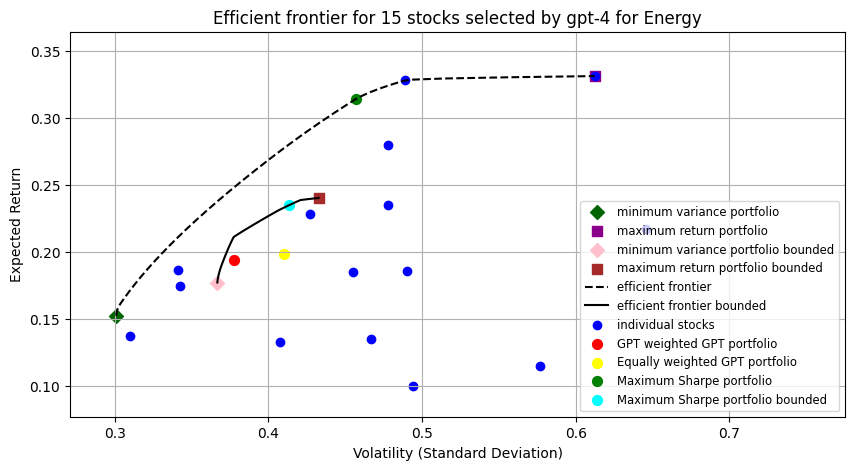

In [33]:
plot_frontiers(df_returns, params_gpt4, sector_name_full, model)

## Plot portfolio performance

In [34]:
# Weights of all portfolios
weights = {
    f"GPT4_weighted_{sector_name}": globals()[f'weights_gpt_{sector_name}'],
    f"GPT4_equal_{sector_name}": globals()[f'eq_weights_{sector_name}'],
    "GPT4 Min Var": w_min_var_bounded15,
    "GPT4 Max Ret": w_max_ret_bounded15,
    "GPT4 Max Sharpe": w_max_sharpe_bounded15
}

In [35]:
temp_stock_return = globals()[f'stock_returns_{sector_name}']
cumulative_returns_gpt = pd.DataFrame(index=temp_stock_return.index)

In [36]:
i = 0
for name, weight in weights.items():
    temp_stock_return = globals()[f'stock_returns_{sector_name}']
    portfolio_return = (temp_stock_return * weight).sum(axis=1)
    cumulative_returns_gpt[name] = (1 + portfolio_return).cumprod()
    i+=1

In [37]:
cumulative_returns_gpt

,GPT4_weighted_energy,GPT4_equal_energy,GPT4 Min Var,GPT4 Max Ret,GPT4 Max Sharpe
Date,,,,,
2023-04-04,0.976241,0.974228,0.978209,0.968053,0.970808
2023-04-05,0.994799,0.990043,0.994889,0.989707,0.991945
2023-04-06,0.980979,0.975432,0.981308,0.973684,0.976280
2023-04-10,0.991041,0.987905,0.990097,0.985479,0.986471
2023-04-11,1.000041,0.998728,0.999894,0.996575,0.997483
...,...,...,...,...,...
2023-11-24,1.019304,1.033570,1.037070,1.016477,1.006809
2023-11-27,1.016055,1.030386,1.034075,1.013888,1.003885
2023-11-28,1.017065,1.030187,1.033966,1.013960,1.004000


In [38]:
index_names = {
    sector_ticker: f'{full_ticker} {sector_name}'
}

cumulative_returns_gpt[index_names[sector_ticker]] = (1 + index_data_outs[ticker]).cumprod()

cumulative_returns_gpt.index = pd.to_datetime(cumulative_returns_gpt.index)
outsample_data = cumulative_returns_gpt.loc[outsample_startdate:outsample_enddate]

fig = go.Figure()


for column in outsample_data.columns:
    if column == f'{full_ticker} {sector_name}':
        fig.add_trace(go.Scatter(x=outsample_data.index,
                                 y=outsample_data[column],
                                 mode='lines',
                                 name=column,
                                 line=dict(width=3, color='red')))
    else:
        fig.add_trace(go.Scatter(x=outsample_data.index,
                                 y=outsample_data[column],
                                 mode='lines',
                                 name=column))


num_asset = len(df_sector)
fig.update_layout(
    title=f'Cumulative Returns of {num_asset} Asset Portfolios (GPT, equal weight) and {full_ticker} ({sector_name_full}) from Apr 23 to Dec 23',
    xaxis_title='Date',
    yaxis_title='Cumulative Returns',
    hovermode="x unified"
)

fig.show()

## Comparing GPT4, GPT3.5, GPT4 preview, Bard, Claude

In [39]:
csv_filename = f'cached/bard_avg_weights_assigned/responses15_auto_{sector_name}.csv'

df_sector_bard = pd.read_csv(csv_filename)

stocks_bard, eq_weights_bard, weights_bard = process_sector_data(df_sector_bard)

# Assign variables dynamically
globals()[f'bard_df_{sector_name}'] = df_sector_bard
globals()[f'bard_stocks_{sector_name}'] = stocks_bard
globals()[f'bard_eq_weights_{sector_name}'] = eq_weights_bard
globals()[f'bard_weights_{sector_name}'] = weights_bard

In [40]:
csv_filename = f'cached/claude_avg_weights_assigned/responses15_auto_{sector_name}.csv'

df_sector_claude = pd.read_csv(csv_filename)

stocks_claude, eq_weights_claude, weights_bard_claude = process_sector_data(df_sector_claude)

# Assign variables dynamically
globals()[f'claude_df_{sector_name}'] = df_sector_claude
globals()[f'claude_stocks_{sector_name}'] = stocks_claude
globals()[f'claude_eq_weights_{sector_name}'] = eq_weights_claude
globals()[f'claude_weights_{sector_name}'] = weights_bard_claude

In [41]:
csv_filename = f'cached/3_avg_weights_assigned/responses15_auto_{sector_name}.csv'

df_sector_gpt3 = pd.read_csv(csv_filename)

stocks_gpt3, eq_weights_gpt3, weights_gpt3 = process_sector_data(df_sector_gpt3)

# Assign variables dynamically
globals()[f'gpt3_df_{sector_name}'] = df_sector_gpt3
globals()[f'gpt3_stocks_{sector_name}'] = stocks_gpt3
globals()[f'gpt3_eq_weights_{sector_name}'] = eq_weights_gpt3
globals()[f'gpt3_weights_{sector_name}'] = weights_gpt3

In [42]:
csv_filename = f'cached/4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'

df_sector_gpt4preview = pd.read_csv(csv_filename)

stocks_gpt4preview, eq_weights_gpt4preview, weights_gpt4preview = process_sector_data(df_sector_gpt4preview)

# Assign variables dynamically
globals()[f'gpt4preview_df_{sector_name}'] = df_sector_gpt4preview
globals()[f'gpt4preview_stocks_{sector_name}'] = stocks_gpt4preview
globals()[f'gpt4preview_eq_weights_{sector_name}'] = eq_weights_gpt4preview
globals()[f'gpt4preview_weights_{sector_name}'] = weights_gpt4preview

In [43]:
ret_front15_3, var_front15_3, ret_max_sharpe15_3, var_max_sharpe15_3, ret_front_bounded15_3, \
    var_front_bounded15_3, ret_max_sharpe_bounded15_3, var_max_sharpe_bounded15_3, w_min_var_bounded15_3, \
    w_max_ret_bounded15_3, w_max_sharpe_bounded15_3 = frontiers(df_returns, globals()[f'gpt3_stocks_{sector_name}'], 200, lbA, ubA, 0.01, 'gpt-3')

In [44]:
ret_front15_4preview, var_front15_4preview, ret_max_sharpe15_4preview, var_max_sharpe15_4preview, ret_front_bounded15_4preview, \
    var_front_bounded15_4preview, ret_max_sharpe_bounded15_4preview, var_max_sharpe_bounded15_4preview, w_min_var_bounded15_4preview, \
    w_max_ret_bounded15_4preview, w_max_sharpe_bounded15_4preview = frontiers(df_returns, globals()[f'gpt4preview_stocks_{sector_name}'], 200, lbA, ubA, 0.01, 'gpt-4_preview')

In [45]:
ret_front15_bard, var_front15_bard, ret_max_sharpe15_bard, var_max_sharpe15_bard, ret_front_bounded15_bard, \
    var_front_bounded15_bard, ret_max_sharpe_bounded15_bard, var_max_sharpe_bounded15_bard, w_min_var_bounded15_bard, \
    w_max_ret_bounded15_bard, w_max_sharpe_bounded15_bard = frontiers(df_returns, globals()[f'bard_stocks_{sector_name}'], 200, lbA, ubA, 0.01, 'bard')

In [46]:
ret_front15_claude, var_front15_claude, ret_max_sharpe15_claude, var_max_sharpe15_claude, ret_front_bounded15_claude, \
    var_front_bounded15_claude, ret_max_sharpe_bounded15_claude, var_max_sharpe_bounded15_claude, w_min_var_bounded15_claude, \
    w_max_ret_bounded15_claude, w_max_sharpe_bounded15_claude = frontiers(df_returns, globals()[f'claude_stocks_{sector_name}'], 200, lbA, ubA, 0.01, 'claude')

In [47]:
temp_stock_return_compare = globals()[f'stock_returns_{sector_name}']
cumulative_returns_gpt_compare = pd.DataFrame(index=temp_stock_return_compare.index)

In [48]:
globals()[f'gpt3_stock_returns_{sector_name}'] = df_returnsOUT[globals()[f'gpt3_stocks_{sector_name}']]
globals()[f'gpt4preview_stock_returns_{sector_name}'] = df_returnsOUT[globals()[f'gpt4preview_stocks_{sector_name}']]
globals()[f'bard_stock_returns_{sector_name}'] = df_returnsOUT[globals()[f'bard_stocks_{sector_name}']]
globals()[f'claude_stock_returns_{sector_name}'] = df_returnsOUT[globals()[f'claude_stocks_{sector_name}']]

In [49]:
weights_gpt4 = {
    f"GPT4_weighted_{sector_name}": globals()[f'weights_gpt_{sector_name}'],
    f"GPT4_equal_{sector_name}": globals()[f'eq_weights_{sector_name}'],
    "GPT4 Min Var": w_min_var_bounded15,
    "GPT4 Max Ret": w_max_ret_bounded15,
    "GPT4 Max Sharpe": w_max_sharpe_bounded15
}

weights_gpt3 = {
    f"GPT3_weighted_{sector_name}": globals()[f'gpt3_weights_{sector_name}'],
    f"GPT3_equal_{sector_name}": globals()[f'gpt3_eq_weights_{sector_name}'],
    "GPT3 Min Var": w_min_var_bounded15_3,
    "GPT3 Max Ret": w_max_ret_bounded15_3,
    "GPT3 Max Sharpe": w_max_sharpe_bounded15_3
}

weights_gpt4preview = {
    f"GPT4preview_weighted_{sector_name}": globals()[f'gpt4preview_weights_{sector_name}'],
    f"GPT4preview_equal_{sector_name}": globals()[f'gpt4preview_eq_weights_{sector_name}'],
    "GPT4preview Min Var": w_min_var_bounded15_4preview,
    "GPT4preview Max Ret": w_max_ret_bounded15_4preview,
    "GPT4preview Max Sharpe": w_max_sharpe_bounded15_4preview
}


weights_bard = {
    f"bard_weighted_{sector_name}": globals()[f'bard_weights_{sector_name}'],
    f"bard_equal_{sector_name}": globals()[f'bard_eq_weights_{sector_name}'],
    "bard Min Var": w_min_var_bounded15_bard,
    "bard Max Ret": w_max_ret_bounded15_bard,
    "bard Max Sharpe": w_max_sharpe_bounded15_bard
}

weights_claude = {
    f"claude_weighted_{sector_name}": globals()[f'claude_weights_{sector_name}'],
    f"claude_equal_{sector_name}": globals()[f'claude_eq_weights_{sector_name}'],
    "claude Min Var": w_min_var_bounded15_claude,
    "claude Max Ret": w_max_ret_bounded15_claude,
    "claude Max Sharpe": w_max_sharpe_bounded15_claude
}

In [50]:
i = 0
for name, weight in weights.items():
    temp_stock_return_compare = globals()[f'stock_returns_{sector_name}']
    portfolio_return_compare = (temp_stock_return_compare * weight).sum(axis=1)
    cumulative_returns_gpt_compare[name] = (1 + portfolio_return_compare).cumprod()
    i+=1

i = 0
for name, weight in weights_gpt3.items():
    temp_stock_return_compare = globals()[f'gpt3_stock_returns_{sector_name}']
    portfolio_return_compare = (temp_stock_return_compare * weight).sum(axis=1)
    cumulative_returns_gpt_compare[name] = (1 + portfolio_return_compare).cumprod()
    i+=1

i = 0
for name, weight in weights_gpt4preview.items():
    temp_stock_return_compare = globals()[f'gpt4preview_stock_returns_{sector_name}']
    portfolio_return_compare = (temp_stock_return_compare * weight).sum(axis=1)
    cumulative_returns_gpt_compare[name] = (1 + portfolio_return_compare).cumprod()
    i+=1

i = 0
for name, weight in weights_bard.items():
    temp_stock_return_compare = globals()[f'bard_stock_returns_{sector_name}']
    portfolio_return_compare = (temp_stock_return_compare * weight).sum(axis=1)
    cumulative_returns_gpt_compare[name] = (1 + portfolio_return_compare).cumprod()
    i+=1


i = 0
for name, weight in weights_claude.items():
    temp_stock_return_compare = globals()[f'claude_stock_returns_{sector_name}']
    portfolio_return_compare = (temp_stock_return_compare * weight).sum(axis=1)
    cumulative_returns_gpt_compare[name] = (1 + portfolio_return_compare).cumprod()
    i+=1

print(cumulative_returns_gpt_compare.columns)


Index(['GPT4_weighted_energy', 'GPT4_equal_energy', 'GPT4 Min Var',
       'GPT4 Max Ret', 'GPT4 Max Sharpe', 'GPT3_weighted_energy',
       'GPT3_equal_energy', 'GPT3 Min Var', 'GPT3 Max Ret', 'GPT3 Max Sharpe',
       'GPT4preview_weighted_energy', 'GPT4preview_equal_energy',
       'GPT4preview Min Var', 'GPT4preview Max Ret', 'GPT4preview Max Sharpe',
       'bard_weighted_energy', 'bard_equal_energy', 'bard Min Var',
       'bard Max Ret', 'bard Max Sharpe', 'claude_weighted_energy',
       'claude_equal_energy', 'claude Min Var', 'claude Max Ret',
       'claude Max Sharpe'],
      dtype='object')


In [51]:
index_names = {
    sector_ticker: f'{full_ticker} {sector_name}'
}

cumulative_returns_gpt_compare[index_names[sector_ticker]] = (1 + index_data_outs[ticker]).cumprod()

cumulative_returns_gpt_compare.index = pd.to_datetime(cumulative_returns_gpt_compare.index)

In [52]:
cumrets_mean = cumulative_returns_gpt_compare.mean().tolist()[:-1]
cumrets_mean = [str(x) for x in cumrets_mean]
with open('metrics/cumulative_returns_all.csv', 'a', encoding='utf-8') as f:
    content = ','.join(cumrets_mean)
    print((f'{sector_name},{content}\n'))
    f.write(f'{sector_name},{content}\n')

energy,0.9959717106800055,1.007155173067786,1.010347414852275,0.9909083637127231,0.9876172882759682,1.0039513530874442,1.0137316196401804,1.0171753993605785,0.9871249189340817,1.0050134269974087,1.0054028644370343,1.0182128837814475,1.0192045426728789,0.9956221147314424,1.0077960214988624,0.9922393359136391,0.9994875090284188,0.9997525075254767,0.9869256958255532,0.9822996651395767,0.9898389019742355,0.9992658255040365,1.0010938018360969,0.987762482783516,0.9803519952646257



In [53]:
print(cumulative_returns_gpt_compare.columns)


Index(['GPT4_weighted_energy', 'GPT4_equal_energy', 'GPT4 Min Var',
       'GPT4 Max Ret', 'GPT4 Max Sharpe', 'GPT3_weighted_energy',
       'GPT3_equal_energy', 'GPT3 Min Var', 'GPT3 Max Ret', 'GPT3 Max Sharpe',
       'GPT4preview_weighted_energy', 'GPT4preview_equal_energy',
       'GPT4preview Min Var', 'GPT4preview Max Ret', 'GPT4preview Max Sharpe',
       'bard_weighted_energy', 'bard_equal_energy', 'bard Min Var',
       'bard Max Ret', 'bard Max Sharpe', 'claude_weighted_energy',
       'claude_equal_energy', 'claude Min Var', 'claude Max Ret',
       'claude Max Sharpe', 'SP500-10 energy'],
      dtype='object')


## Difference between benchmark (index) and portfolio

In [54]:
cumulative_returns_diff_comp = cumulative_returns_gpt_compare.copy()

cumulative_returns_diff_comp[f'GPT4_weighted_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4_weighted_{sector_name}']
cumulative_returns_diff_comp[f'GPT4_equal_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4_equal_{sector_name}']
cumulative_returns_diff_comp[f'GPT4 Min Var'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4 Min Var']
cumulative_returns_diff_comp[f'GPT4 Max Ret'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4 Max Ret']
cumulative_returns_diff_comp[f'GPT4 Max Sharpe'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4 Max Sharpe']

cumulative_returns_diff_comp[f'GPT3_weighted_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT3_weighted_{sector_name}']
cumulative_returns_diff_comp[f'GPT3_equal_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT3_equal_{sector_name}']
cumulative_returns_diff_comp[f'GPT3 Min Var'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT3 Min Var']
cumulative_returns_diff_comp[f'GPT3 Max Ret'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT3 Max Ret']
cumulative_returns_diff_comp[f'GPT3 Max Sharpe'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT3 Max Sharpe']

cumulative_returns_diff_comp[f'GPT4preview_weighted_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4preview_weighted_{sector_name}']
cumulative_returns_diff_comp[f'GPT4preview_equal_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4preview_equal_{sector_name}']
cumulative_returns_diff_comp[f'GPT4preview Min Var'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4preview Min Var']
cumulative_returns_diff_comp[f'GPT4preview Max Ret'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4preview Max Ret']
cumulative_returns_diff_comp[f'GPT4preview Max Sharpe'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4preview Max Sharpe']

cumulative_returns_diff_comp[f'bard_weighted_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'bard_weighted_{sector_name}']
cumulative_returns_diff_comp[f'bard_equal_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'bard_equal_{sector_name}']
cumulative_returns_diff_comp[f'bard Min Var'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'bard Min Var']
cumulative_returns_diff_comp[f'bard Max Ret'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'bard Max Ret']
cumulative_returns_diff_comp[f'bard Max Sharpe'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'bard Max Sharpe']

cumulative_returns_diff_comp[f'claude_weighted_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'claude_weighted_{sector_name}']
cumulative_returns_diff_comp[f'claude_equal_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'claude_equal_{sector_name}']
cumulative_returns_diff_comp[f'claude Min Var'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'claude Min Var']
cumulative_returns_diff_comp[f'claude Max Ret'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'claude Max Ret']
cumulative_returns_diff_comp[f'claude Max Sharpe'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'claude Max Sharpe']



In [55]:
cumulative_returns_diff_comp = cumulative_returns_diff_comp.drop(f'{full_ticker} {sector_name}', axis=1)

Negative value means portfolio outperforms the index (because it is the difference between index and portfolio performance, not vice versa).

In [56]:
cumulative_returns_diff_comp.mean()

GPT4_weighted_energy          -0.019866
GPT4_equal_energy             -0.031049
GPT4 Min Var                  -0.034242
GPT4 Max Ret                  -0.014803
GPT4 Max Sharpe               -0.011511
GPT3_weighted_energy          -0.027846
GPT3_equal_energy             -0.037626
GPT3 Min Var                  -0.041070
GPT3 Max Ret                  -0.011019
GPT3 Max Sharpe               -0.028908
GPT4preview_weighted_energy   -0.029297
GPT4preview_equal_energy      -0.042107
GPT4preview Min Var           -0.043099
GPT4preview Max Ret           -0.019516
GPT4preview Max Sharpe        -0.031690
bard_weighted_energy          -0.016134
bard_equal_energy             -0.023382
bard Min Var                  -0.023647
bard Max Ret                  -0.010820
bard Max Sharpe               -0.006194
claude_weighted_energy        -0.013733
claude_equal_energy           -0.023160
claude Min Var                -0.024988
claude Max Ret                -0.011657
claude Max Sharpe             -0.004246


The table above is used to compose the Table 5.2 with portfolio performances based on out-of-sample cumulative returns.

In [57]:
outsample_data_diff_comp = cumulative_returns_diff_comp.loc[outsample_startdate:outsample_enddate]

fig = go.Figure()

for column in outsample_data_diff_comp.columns:
    fig.add_trace(go.Scatter(x=outsample_data_diff_comp.index.sort_values(),
                                y=outsample_data_diff_comp[column],
                                mode='lines',
                                name=column))

fig.add_trace(go.Scatter(x=outsample_data.index.sort_values(),
                            y=np.array([0] * len(outsample_data)),
                            mode='lines',
                            name=column,
                            line=dict(width=2, color='red')))

num_asset = len(df_sector)
fig.update_layout(
    title=f'Differences between index performance ({full_ticker} {sector_name}) and {num_asset} asset portfolios from Apr 23 to Dec 23',
    xaxis_title='Date',
    yaxis_title='Difference',
    hovermode="x unified"
)

fig.show()



## Volatilities

In [58]:
for one_model in ['GPT4', 'GPT4preview', 'GPT3', 'bard', 'claude']:

    sector_mean = cumulative_returns_gpt_compare[f'{one_model}_weighted_{sector_name}'].mean()
    sector_diff_sq = cumulative_returns_gpt_compare[f'{one_model}_weighted_{sector_name}'].apply(lambda x: (x - sector_mean)**2)
    sector_sumdiff = sector_diff_sq.sum() / cumulative_returns_gpt_compare.size
    sector_volatility = round(sqrt(sector_sumdiff), 5)

    print(sector_name, sector_volatility, one_model)
    with open('metrics/portfolio_volatilities.csv', 'a', encoding='utf-8') as f:
        f.write(f'{one_model},{sector_name},{sector_volatility}\n')



energy 0.01144 GPT4
energy 0.01225 GPT4preview
energy 0.01212 GPT3
energy 0.0116 bard
energy 0.01112 claude


## Sector index volatility

In [59]:
globals()[f'insample_stock_returns_{sector_name}'] = df_returns[globals()[f'stocks_{sector_name}']]
temp_stock_return_insample = globals()[f'insample_stock_returns_{sector_name}']
cumulative_returns_gpt_insample = pd.DataFrame(index=temp_stock_return_insample.index)
cumulative_returns_gpt_insample

i = 0
for name, weight in weights.items():
    temp_stock_return = globals()[f'insample_stock_returns_{sector_name}']
    portfolio_return = (temp_stock_return * weight).sum(axis=1)
    cumulative_returns_gpt_insample[name] = (1 + portfolio_return).cumprod()
    i+=1

print(cumulative_returns_gpt_insample.columns)

cumulative_returns_gpt_insample[index_names[sector_ticker]] = (1 + index_data_ins[ticker]).cumprod()

cumulative_returns_gpt_insample.index = pd.to_datetime(cumulative_returns_gpt_insample.index)
insample_data = cumulative_returns_gpt_insample.loc[insample_startdate:insample_enddate]


insample_data

Index(['GPT4_weighted_energy', 'GPT4_equal_energy', 'GPT4 Min Var',
       'GPT4 Max Ret', 'GPT4 Max Sharpe'],
      dtype='object')


,GPT4_weighted_energy,GPT4_equal_energy,GPT4 Min Var,GPT4 Max Ret,GPT4 Max Sharpe,SP500-10 energy
Date,,,,,,
2018-04-09,1.065312,1.071146,1.063382,1.073063,1.067160,1.060165
2018-04-16,1.104417,1.113697,1.106800,1.118893,1.109839,1.087746
2018-04-23,1.110095,1.123249,1.115970,1.124633,1.114762,1.094375
2018-04-30,1.113745,1.130189,1.125283,1.139853,1.125092,1.094496
2018-05-07,1.152579,1.169806,1.159613,1.186436,1.170970,1.135557
...,...,...,...,...,...,...
2023-02-27,1.903675,1.845867,1.806656,2.157262,2.190580,1.334472
2023-03-06,1.806628,1.734283,1.704832,2.029274,2.060055,1.263118
2023-03-13,1.686207,1.607021,1.591573,1.885389,1.909965,1.174448


### In-sample sector index volatility

In [60]:
sector_mean = insample_data[f'{full_ticker} {sector_name}'].mean()
sector_mean

sector_diff_sq = insample_data[f'{full_ticker} {sector_name}'].apply(lambda x: (x - sector_mean)**2)
sector_sumdiff = sector_diff_sq.sum() / cumulative_returns_gpt_compare.size
sector_volatility = round(sqrt(sector_sumdiff), 5)

print(sector_name, sector_volatility)

csv_path = f'metrics/sector_index_volatility_insample.csv'

with open(csv_path, 'a', encoding='utf-8') as f:
    f.write(f'{sector_name},{sector_volatility}')
    f.write('\n')

energy 0.06126


### Out-of-sample sector index volatility

In [61]:
sector_mean = outsample_data[f'{full_ticker} {sector_name}'].mean()
sector_mean

sector_diff_sq = outsample_data[f'{full_ticker} {sector_name}'].apply(lambda x: (x - sector_mean)**2)
sector_sumdiff = sector_diff_sq.sum() / cumulative_returns_gpt_compare.size
sector_volatility = round(sqrt(sector_sumdiff), 5)

print(sector_name, sector_volatility)

csv_path = f'metrics/sector_index_volatility_outsample.csv'

with open(csv_path, 'a', encoding='utf-8') as f:
    f.write(f'{sector_name},{sector_volatility}')
    f.write('\n')

energy 0.00923


## Portfolio performance

In [62]:
index_names = {
    sector_ticker: f'{full_ticker} {sector_name}'
}

cumulative_returns_gpt_compare[index_names[sector_ticker]] = (1 + index_data_outs[ticker]).cumprod()

cumulative_returns_gpt_compare.index = pd.to_datetime(cumulative_returns_gpt_compare.index)
outsample_data = cumulative_returns_gpt_compare.loc[outsample_startdate:outsample_enddate]

fig = go.Figure()

for i, column in enumerate(outsample_data.columns):
    if column == f'{full_ticker} {sector_name}':
        fig.add_trace(go.Scatter(x=outsample_data.index,
                                 y=outsample_data[column],
                                 mode='lines',
                                 name=column,
                                 line=dict(width=3, color='red')))

    else:
        fig.add_trace(go.Scatter(x=outsample_data.index,
                                 y=outsample_data[column],
                                 mode='lines',
                                 name=column))

num_asset = len(df_sector)
fig.update_layout(
    title=f'Cumulative Returns of Portfolios composed by different LLMs and {full_ticker} ({sector_name_full}) from Apr 23 to Dec 23',
    xaxis_title='Date',
    yaxis_title='Cumulative Returns',
    hovermode="x unified",
    height=600
)

fig.update_layout(legend=dict(orientation = "h", yanchor="bottom",y=-1.1,xanchor="left", x=0))


fig.show()
